<a href="https://colab.research.google.com/github/Anthonerp/HoangIntroToMachineLearning/blob/main/Homework_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import fashion_mnist, mnist

In [2]:
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [3]:
CLASS_NAMES_FASHION = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

CLASS_NAMES_MNIST = [str(i) for i in range(10)]


def preprocess_data(x_train, y_train, x_test, y_test):
    # Normalize pixel values to [0, 1]
    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0

    # Add channel dimension: (28, 28) -> (28, 28, 1)
    x_train = np.expand_dims(x_train, axis=-1)
    x_test = np.expand_dims(x_test, axis=-1)

    return x_train, y_train, x_test, y_test


def build_baseline_model():
    # Approximation of the standard chapter convnet:
    # Conv -> Pool -> Conv -> Pool -> Flatten -> Dense -> Dense
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),   # first Dense layer
        layers.Dense(10, activation="softmax")
    ])
    return model


def build_no_first_dense_model():
    # Removes the first Dense layer after Flatten
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(10, activation="softmax")
    ])
    return model


def build_with_4096_dense_model():
    # Adds a Dense(4096) layer before the existing Dense layers
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(4096, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    return model


def compile_model(model):
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def train_and_evaluate(model, x_train, y_train, x_test, y_test, epochs=5, batch_size=128, verbose=1):
    model = compile_model(model)

    start_time = time.time()
    history = model.fit(
        x_train, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose
    )
    end_time = time.time()

    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
    training_time = end_time - start_time

    return {
        "model": model,
        "history": history,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "training_time_sec": training_time
    }


def plot_history(history, title_prefix="Model"):
    hist = history.history
    epochs = range(1, len(hist["accuracy"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, hist["accuracy"], label="Training Accuracy")
    plt.plot(epochs, hist["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, hist["loss"], label="Training Loss")
    plt.plot(epochs, hist["val_loss"], label="Validation Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

In [4]:
(x_train_fashion, y_train_fashion), (x_test_fashion, y_test_fashion) = fashion_mnist.load_data()

x_train_fashion, y_train_fashion, x_test_fashion, y_test_fashion = preprocess_data(
    x_train_fashion, y_train_fashion, x_test_fashion, y_test_fashion
)

print("Fashion-MNIST training shape:", x_train_fashion.shape)
print("Fashion-MNIST test shape:", x_test_fashion.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Fashion-MNIST training shape: (60000, 28, 28, 1)
Fashion-MNIST test shape: (10000, 28, 28, 1)


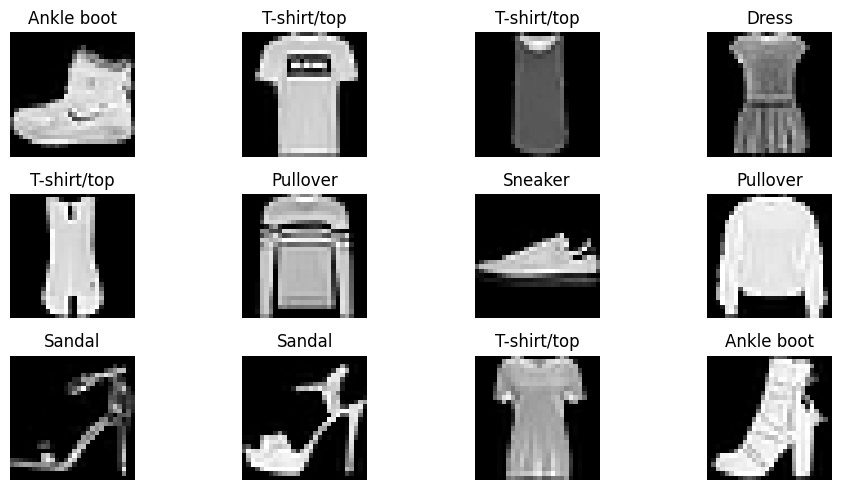

In [5]:
plt.figure(figsize=(10, 5))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train_fashion[i].squeeze(), cmap="gray")
    plt.title(CLASS_NAMES_FASHION[y_train_fashion[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
fashion_baseline = train_and_evaluate(
    model=build_baseline_model(),
    x_train=x_train_fashion,
    y_train=y_train_fashion,
    x_test=x_test_fashion,
    y_test=y_test_fashion,
    epochs=5,
    batch_size=128,
    verbose=1
)

print("Fashion-MNIST Baseline Test Accuracy:", round(fashion_baseline["test_accuracy"], 4))
print("Fashion-MNIST Baseline Training Time (sec):", round(fashion_baseline["training_time_sec"], 2))

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 58ms/step - accuracy: 0.7194 - loss: 0.7898 - val_accuracy: 0.8593 - val_loss: 0.4022
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 57ms/step - accuracy: 0.8646 - loss: 0.3770 - val_accuracy: 0.8777 - val_loss: 0.3432
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 59ms/step - accuracy: 0.8807 - loss: 0.3238 - val_accuracy: 0.8913 - val_loss: 0.3080
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.8951 - loss: 0.2880 - val_accuracy: 0.8977 - val_loss: 0.2877
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.9046 - loss: 0.2600 - val_accuracy: 0.9020 - val_loss: 0.2775
Fashion-MNIST Baseline Test Accuracy: 0.8994
Fashion-MNIST Baseline Training Time (sec): 155.53


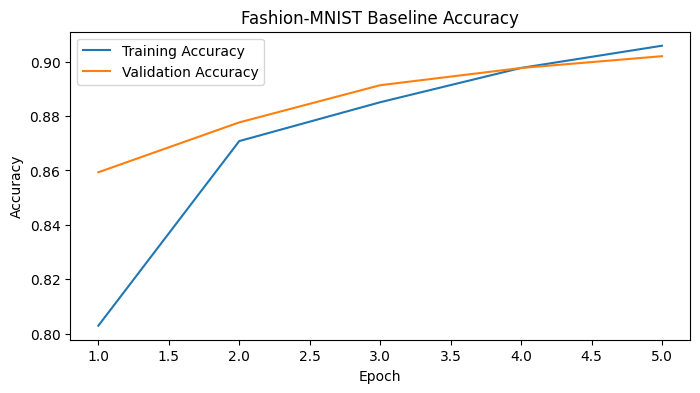

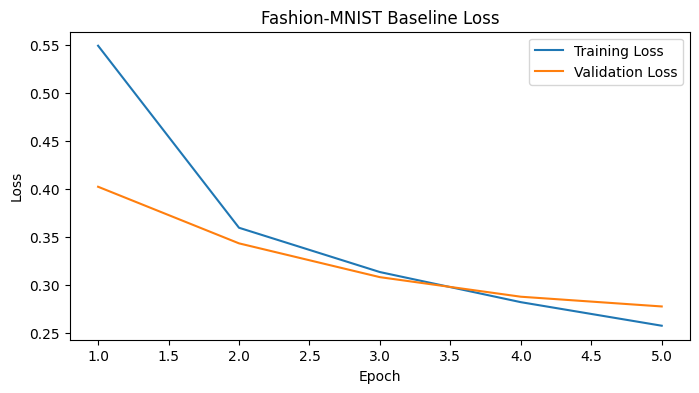

In [7]:
plot_history(fashion_baseline["history"], title_prefix="Fashion-MNIST Baseline")

In [8]:
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()

x_train_mnist, y_train_mnist, x_test_mnist, y_test_mnist = preprocess_data(
    x_train_mnist, y_train_mnist, x_test_mnist, y_test_mnist
)

print("MNIST training shape:", x_train_mnist.shape)
print("MNIST test shape:", x_test_mnist.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MNIST training shape: (60000, 28, 28, 1)
MNIST test shape: (10000, 28, 28, 1)


In [9]:
mnist_baseline = train_and_evaluate(
    model=build_baseline_model(),
    x_train=x_train_mnist,
    y_train=y_train_mnist,
    x_test=x_test_mnist,
    y_test=y_test_mnist,
    epochs=5,
    batch_size=128,
    verbose=1
)

print("MNIST Baseline Test Accuracy:", round(mnist_baseline["test_accuracy"], 4))
print("MNIST Baseline Training Time (sec):", round(mnist_baseline["training_time_sec"], 2))

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 58ms/step - accuracy: 0.8542 - loss: 0.5130 - val_accuracy: 0.9830 - val_loss: 0.0602
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.9809 - loss: 0.0623 - val_accuracy: 0.9875 - val_loss: 0.0438
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - accuracy: 0.9875 - loss: 0.0409 - val_accuracy: 0.9890 - val_loss: 0.0385
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - accuracy: 0.9910 - loss: 0.0303 - val_accuracy: 0.9892 - val_loss: 0.0365
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - accuracy: 0.9936 - loss: 0.0235 - val_accuracy: 0.9902 - val_loss: 0.0376
MNIST Baseline Test Accuracy: 0.9889
MNIST Baseline Training Time (sec): 117.45


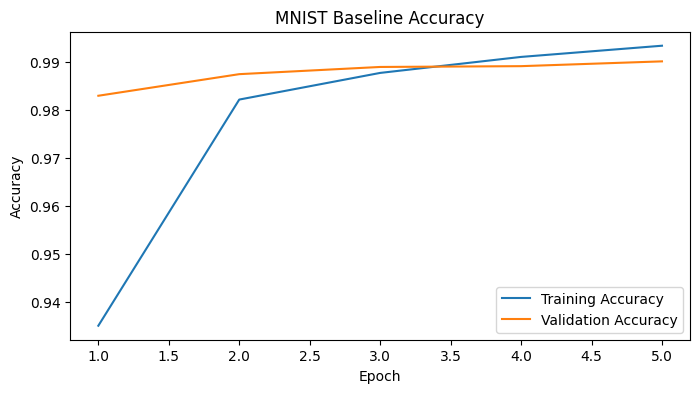

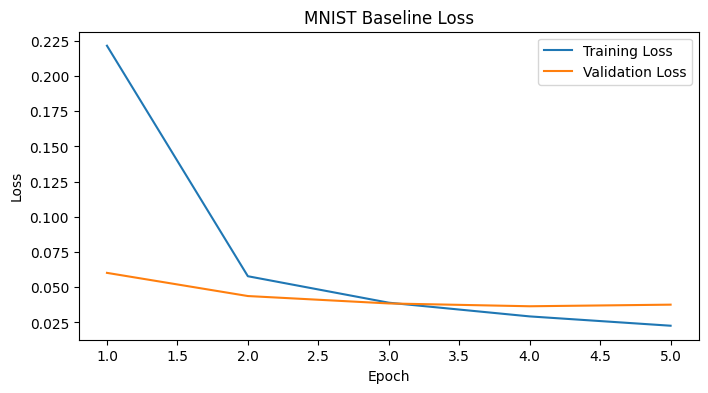

In [10]:
plot_history(mnist_baseline["history"], title_prefix="MNIST Baseline")

In [11]:
fashion_no_dense = train_and_evaluate(
    model=build_no_first_dense_model(),
    x_train=x_train_fashion,
    y_train=y_train_fashion,
    x_test=x_test_fashion,
    y_test=y_test_fashion,
    epochs=5,
    batch_size=128,
    verbose=1
)

print("Fashion-MNIST No-First-Dense Test Accuracy:", round(fashion_no_dense["test_accuracy"], 4))
print("Fashion-MNIST No-First-Dense Training Time (sec):", round(fashion_no_dense["training_time_sec"], 2))

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.6830 - loss: 0.9006 - val_accuracy: 0.8385 - val_loss: 0.4471
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.8498 - loss: 0.4214 - val_accuracy: 0.8682 - val_loss: 0.3758
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - accuracy: 0.8722 - loss: 0.3611 - val_accuracy: 0.8803 - val_loss: 0.3365
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.8836 - loss: 0.3265 - val_accuracy: 0.8893 - val_loss: 0.3122
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.8919 - loss: 0.3023 - val_accuracy: 0.8933 - val_loss: 0.2967
Fashion-MNIST No-First-Dense Test Accuracy: 0.8912
Fashion-MNIST No-First-Dense Training Time (sec): 150.03


In [12]:
fashion_4096 = train_and_evaluate(
    model=build_with_4096_dense_model(),
    x_train=x_train_fashion,
    y_train=y_train_fashion,
    x_test=x_test_fashion,
    y_test=y_test_fashion,
    epochs=5,
    batch_size=128,
    verbose=1
)

print("Fashion-MNIST + Dense(4096) Test Accuracy:", round(fashion_4096["test_accuracy"], 4))
print("Fashion-MNIST + Dense(4096) Training Time (sec):", round(fashion_4096["training_time_sec"], 2))

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 92s 216ms/step - accuracy: 0.7565 - loss: 0.6579 - val_accuracy: 0.8680 - val_loss: 0.3767
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 138s 206ms/step - accuracy: 0.8829 - loss: 0.3193 - val_accuracy: 0.8867 - val_loss: 0.3282
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 88s 208ms/step - accuracy: 0.9037 - loss: 0.2625 - val_accuracy: 0.9010 - val_loss: 0.2877
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 140s 205ms/step - accuracy: 0.9187 - loss: 0.2196 - val_accuracy: 0.9052 - val_loss: 0.2853
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 86s 205ms/step - accuracy: 0.9322 - loss: 0.1856 - val_accuracy: 0.9068 - val_loss: 0.2930
Fashion-MNIST + Dense(4096) Test Accuracy: 0.8998
Fashion-MNIST + Dense(4096) Training Time (sec): 544.76


In [13]:
print("Baseline model summary:")
build_baseline_model().summary()

print("\nNo-first-Dense model summary:")
build_no_first_dense_model().summary()

print("\nDense(4096) model summary:")
build_with_4096_dense_model().summary()

Baseline model summary:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

...

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4096)           │     6,557,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,102,218 (27.09 MB)

 Trainable params: 7,102,218 (27.09 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
results = [
    {
        "Dataset": "Fashion-MNIST",
        "Model": "Baseline ConvNet",
        "Test Accuracy": fashion_baseline["test_accuracy"],
        "Training Time (sec)": fashion_baseline["training_time_sec"]
    },
    {
        "Dataset": "MNIST",
        "Model": "Baseline ConvNet",
        "Test Accuracy": mnist_baseline["test_accuracy"],
        "Training Time (sec)": mnist_baseline["training_time_sec"]
    },
    {
        "Dataset": "Fashion-MNIST",
        "Model": "No First Dense Layer",
        "Test Accuracy": fashion_no_dense["test_accuracy"],
        "Training Time (sec)": fashion_no_dense["training_time_sec"]
    },
    {
        "Dataset": "Fashion-MNIST",
        "Model": "Added Dense(4096)",
        "Test Accuracy": fashion_4096["test_accuracy"],
        "Training Time (sec)": fashion_4096["training_time_sec"]
    }
]

for row in results:
    row["Test Accuracy"] = round(row["Test Accuracy"], 4)
    row["Training Time (sec)"] = round(row["Training Time (sec)"], 2)

results

[{'Dataset': 'Fashion-MNIST',
  'Model': 'Baseline ConvNet',
  'Test Accuracy': 0.8994,
  'Training Time (sec)': 155.53},
 {'Dataset': 'MNIST',
  'Model': 'Baseline ConvNet',
  'Test Accuracy': 0.9889,
  'Training Time (sec)': 117.45},
 {'Dataset': 'Fashion-MNIST',
  'Model': 'No First Dense Layer',
  'Test Accuracy': 0.8912,
  'Training Time (sec)': 150.03},
 {'Dataset': 'Fashion-MNIST',
  'Model': 'Added Dense(4096)',
  'Test Accuracy': 0.8998,
  'Training Time (sec)': 544.76}]

In [15]:
import pandas as pd

df_results = pd.DataFrame(results)
df_results

,Dataset,Model,Test Accuracy,Training Time (sec)
0,Fashion-MNIST,Baseline ConvNet,0.8994,155.53
1,MNIST,Baseline ConvNet,0.9889,117.45
2,Fashion-MNIST,No First Dense Layer,0.8912,150.03
3,Fashion-MNIST,Added Dense(4096),0.8998,544.76


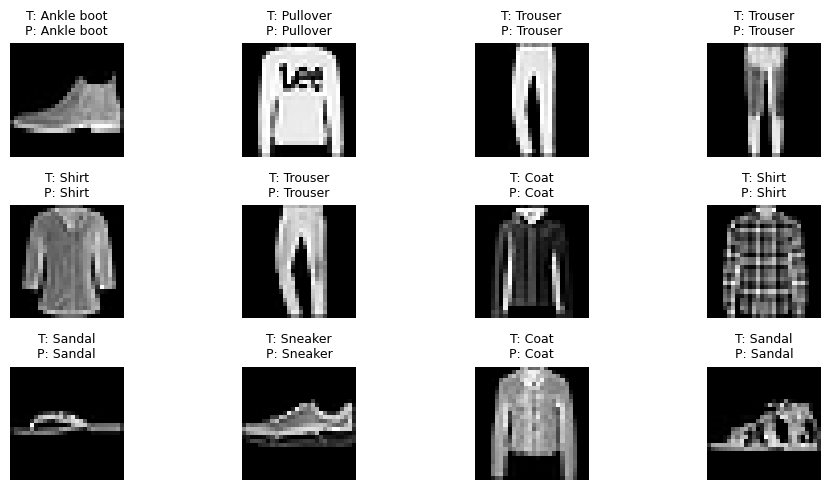

In [16]:
model = fashion_baseline["model"]
pred_probs = model.predict(x_test_fashion[:12], verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)

plt.figure(figsize=(10, 5))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test_fashion[i].squeeze(), cmap="gray")
    true_label = CLASS_NAMES_FASHION[y_test_fashion[i]]
    pred_label = CLASS_NAMES_FASHION[pred_labels[i]]
    plt.title(f"T: {true_label}\nP: {pred_label}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [17]:
print("Discussion:")
print()
print("1. Fashion-MNIST vs. MNIST")
print("   Using the same baseline convnet, MNIST usually achieves higher accuracy than Fashion-MNIST.")
print("   That is expected because handwritten digits are generally easier to separate than clothing items,")
print("   many of which have more visual overlap (for example shirt, pullover, and coat).")
print()
print("2. Training time comparison")
print("   Training times for MNIST and Fashion-MNIST are often similar because both datasets have the same")
print("   number of images and the same image size (28x28 grayscale). Small differences usually come from")
print("   hardware load and randomness during training.")
print()
print("3. Removing the first Dense layer")
print("   Removing the Dense(128) layer usually lowers accuracy because the model has less capacity to learn")
print("   high-level combinations of features extracted by the convolutional layers.")
print()
print("4. Adding Dense(4096)")
print("   Adding a very large Dense layer may slightly improve accuracy, stay about the same, or even hurt")
print("   generalization depending on the run. It almost always increases training time significantly because")
print("   it adds a very large number of parameters.")
print()
print("5. Overall conclusion")
print("   The baseline convnet is usually a strong balance between accuracy and training speed. The no-Dense")
print("   version is simpler but often less accurate, while the 4096-neuron Dense version is much more")
print("   expensive and may not provide enough extra accuracy to justify the cost.")

Discussion:

1. Fashion-MNIST vs. MNIST
   Using the same baseline convnet, MNIST usually achieves higher accuracy than Fashion-MNIST.
   That is expected because handwritten digits are generally easier to separate than clothing items,
   many of which have more visual overlap (for example shirt, pullover, and coat).

2. Training time comparison
   Training times for MNIST and Fashion-MNIST are often similar because both datasets have the same
   number of images and the same image size (28x28 grayscale). Small differences usually come from
   hardware load and randomness during training.

3. Removing the first Dense layer
   Removing the Dense(128) layer usually lowers accuracy because the model has less capacity to learn
   high-level combinations of features extracted by the convolutional layers.

4. Adding Dense(4096)
   Adding a very large Dense layer may slightly improve accuracy, stay about the same, or even hurt
   generalization depending on the run. It almost always increases